**STEP 1: IMPORT LIBRARIES**

In [1]:
# ==========================================================
# STEP 1 : IMPORT LIBRARIES
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

print("All Libraries Imported Successfully.")

All Libraries Imported Successfully.


**STEP 2: LOAD DATASET**

In [2]:
# ==========================================================
# STEP 2 : LOAD DATASET
# ==========================================================
data = pd.read_csv("online_education_dataset.csv")

print("Dataset Loaded Successfully.")

# DISPLAY DATASET

print("\nFirst 5 Rows")
print(data.head())

print("\nLast 5 Rows")
print(data.tail())

# DATASET SHAPE
print("Number of Rows and Columns")
print(data.shape)

#COLUMN NAMES
print("\nColumn Names")
print(data.columns)

Dataset Loaded Successfully.

First 5 Rows
   id_student gender                region      highest_education  \
0       11391      M   East Anglian Region       HE Qualification   
1       28400      F              Scotland       HE Qualification   
2       30268      F  North Western Region  A Level or Equivalent   
3       31604      F     South East Region  A Level or Equivalent   
4       32885      F  West Midlands Region     Lower Than A Level   

   studied_credits imd_band  total_clicks  avg_score engagement_level  \
0              240  90-100%         934.0       82.0           Medium   
1               60   20-30%        1435.0       66.4           Medium   
2               60   30-40%         281.0        NaN              Low   
3               60   50-60%        2158.0       76.0             High   
4               60   50-60%        1034.0       54.4           Medium   

  performance_level      risk_level  pass_flag  dropout_flag final_result  
0              High        

**STEP 3: DATASET INFORMATION**

In [3]:
# ==========================================================
# STEP 3: DATASET INFORMATION
# ==========================================================

print("\nDataset Information")

data.info()


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         32593 non-null  int64  
 1   gender             32593 non-null  str    
 2   region             32593 non-null  str    
 3   highest_education  32593 non-null  str    
 4   studied_credits    32593 non-null  int64  
 5   imd_band           31482 non-null  str    
 6   total_clicks       29741 non-null  float64
 7   avg_score          26727 non-null  float64
 8   engagement_level   29741 non-null  str    
 9   performance_level  26695 non-null  str    
 10  risk_level         29741 non-null  str    
 11  pass_flag          32593 non-null  int64  
 12  dropout_flag       32593 non-null  int64  
 13  final_result       32593 non-null  str    
dtypes: float64(2), int64(4), str(8)
memory usage: 5.4 MB


STEP **4** : **DATA CLEANING**

In [4]:
# ==========================================================
# Check missing valus
# ==========================================================
print("\nMissing Values in Each Column")
print(data.isnull().sum())
print("\nTotal Missing Values:", data.isnull().sum().sum())

# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================
# Numerical Columns
num_cols = data.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())
# Categorical Columns
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])
print("\nMissing Values After Handling")
print(data.isnull().sum())

# ==========================================================
# REMOVE DUPLICATES
# ==========================================================

print("\nShape Before Removing Duplicates")
print(data.shape)

data = data.drop_duplicates()

print("\nShape After Removing Duplicates")
print(data.shape)


Missing Values in Each Column
id_student              0
gender                  0
region                  0
highest_education       0
studied_credits         0
imd_band             1111
total_clicks         2852
avg_score            5866
engagement_level     2852
performance_level    5898
risk_level           2852
pass_flag               0
dropout_flag            0
final_result            0
dtype: int64

Total Missing Values: 21431

Missing Values After Handling
id_student           0
gender               0
region               0
highest_education    0
studied_credits      0
imd_band             0
total_clicks         0
avg_score            0
engagement_level     0
performance_level    0
risk_level           0
pass_flag            0
dropout_flag         0
final_result         0
dtype: int64

Shape Before Removing Duplicates
(32593, 14)

Shape After Removing Duplicates
(31237, 14)


**CLEANED DATASET**

In [5]:
# ==========================================================
#  CLEANED DATASET
# ==========================================================

print("\nFirst 5 Rows After Cleaning")
print(data.head())


First 5 Rows After Cleaning
   id_student gender                region      highest_education  \
0       11391      M   East Anglian Region       HE Qualification   
1       28400      F              Scotland       HE Qualification   
2       30268      F  North Western Region  A Level or Equivalent   
3       31604      F     South East Region  A Level or Equivalent   
4       32885      F  West Midlands Region     Lower Than A Level   

   studied_credits imd_band  total_clicks  avg_score engagement_level  \
0              240  90-100%         934.0  82.000000           Medium   
1               60   20-30%        1435.0  66.400000           Medium   
2               60   30-40%         281.0  75.714286              Low   
3               60   50-60%        2158.0  76.000000             High   
4               60   50-60%        1034.0  54.400000           Medium   

  performance_level      risk_level  pass_flag  dropout_flag final_result  
0              High        Low Risk      

**STEP 5 :** **EXPLORATORY DATA ANALYSIS(EDA)**

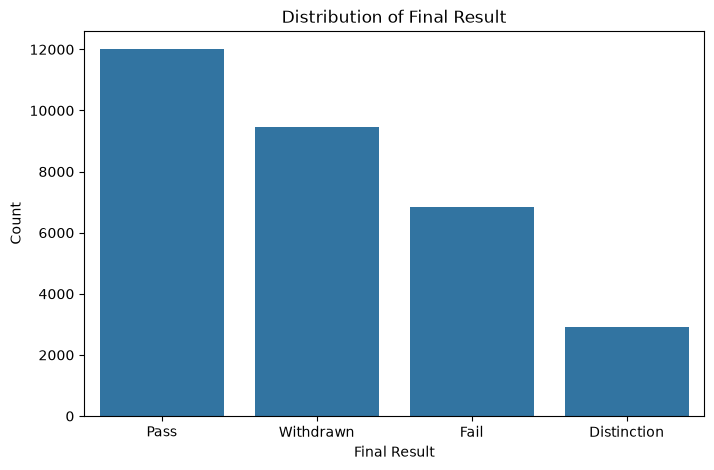

In [6]:
# ==========================================================
# STEP 5 :EXPLORATORY DATA ANALYSIS(EDA)
#===========================================================

# TARGET VARIABLE DISTRIBUTION
plt.figure(figsize=(8,5))
sns.countplot(x="final_result", data=data)
plt.title("Distribution of Final Result")
plt.xlabel("Final Result")
plt.ylabel("Count")
plt.show()

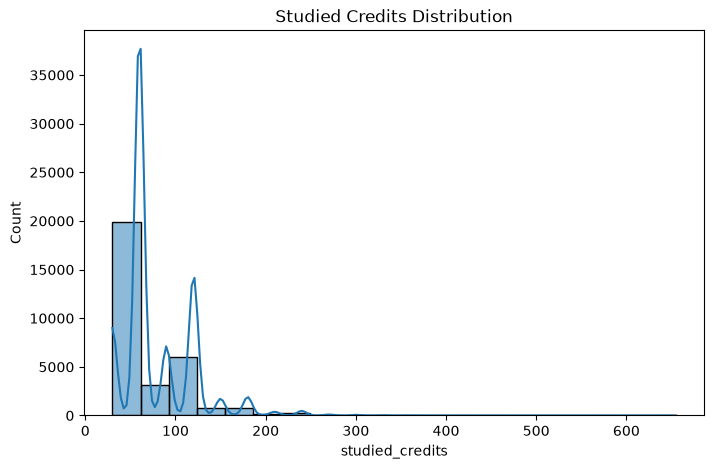

In [7]:
# STUDIED CREDITS
plt.figure(figsize=(8,5))
sns.histplot(data["studied_credits"], bins=20, kde=True)
plt.title("Studied Credits Distribution")
plt.show()

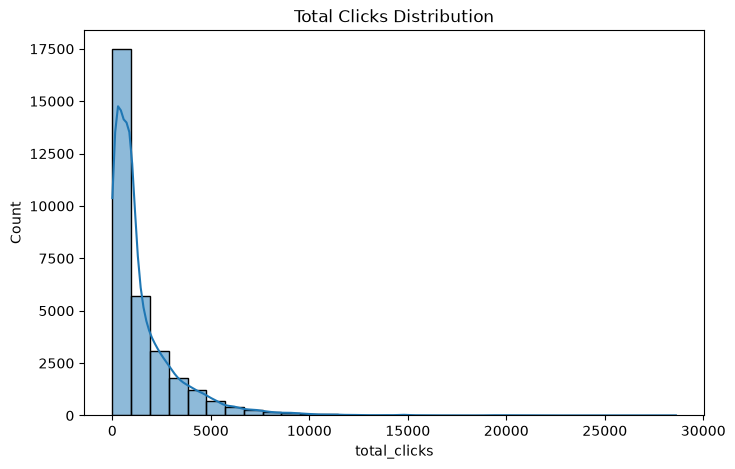

In [8]:
# TOTAL CLICKS
plt.figure(figsize=(8,5))
sns.histplot(data["total_clicks"], bins=30, kde=True)
plt.title("Total Clicks Distribution")
plt.show()

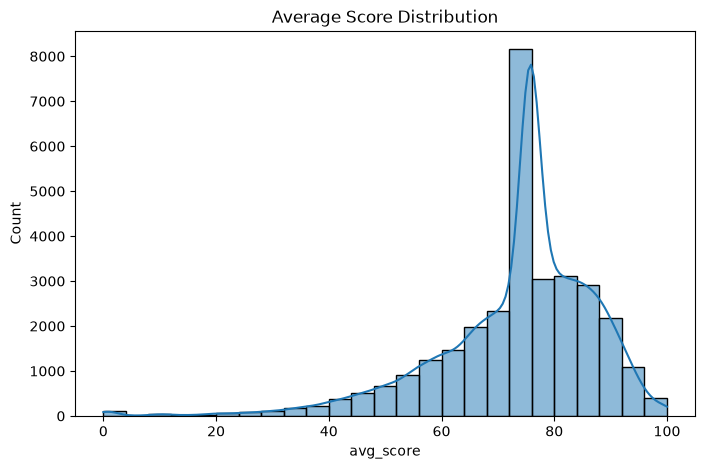

In [9]:

# AVERAGE SCORE
plt.figure(figsize=(8,5))
sns.histplot(data["avg_score"], bins=25, kde=True)
plt.title("Average Score Distribution")
plt.show()

**STEP 6 : LABEL ENCODING**

In [10]:
# ==========================================================
#  STEP 6 : LABEL ENCODING
# ==========================================================

label_encoder = LabelEncoder()

categorical_columns = data.select_dtypes(include=['object']).columns

print("\nCategorical Columns:")
print(categorical_columns)

for column in categorical_columns:
    data[column] = label_encoder.fit_transform(data[column])

print("\nCategorical Features Encoded Successfully.")
data.head()
print(data)


Categorical Columns:
Index(['gender', 'region', 'highest_education', 'imd_band', 'engagement_level',
       'performance_level', 'risk_level', 'final_result'],
      dtype='str')

Categorical Features Encoded Successfully.
       id_student  gender  region  highest_education  studied_credits  \
0           11391       1       0                  1              240   
1           28400       0       6                  1               60   
2           30268       0       5                  0               60   
3           31604       0       7                  0               60   
4           32885       0      11                  2               60   
...           ...     ...     ...                ...              ...   
32588     2640965       0      10                  2               30   
32589     2645731       0       0                  2               30   
32590     2648187       0       8                  0               30   
32591     2679821       0       7             

**STEP 7 : FEATURE SELECTION**

In [11]:
# ==========================================================
#  STEP 7 : FEATURE SELECTION
# ==========================================================
X = data.drop("final_result", axis=1)

y = data["final_result"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nSelected Features")
print(X.columns)

Features Shape : (31237, 13)
Target Shape : (31237,)

Selected Features
Index(['id_student', 'gender', 'region', 'highest_education',
       'studied_credits', 'imd_band', 'total_clicks', 'avg_score',
       'engagement_level', 'performance_level', 'risk_level', 'pass_flag',
       'dropout_flag'],
      dtype='str')


**STEP 8: FEATURE REDUCTION**

In [12]:
#==========================================================
# STEP 8 : FEATURE REDUCTION
#==========================================================
# Re-initialize X and y from data to ensure consistent state for feature selection
# This prevents errors if the cell is run multiple times and X was previously modified.
X = data.drop("final_result", axis=1) # Ensure X still contains 'id_student' at this point
y = data["final_result"]

# Exclude 'id_student' from feature selection as it is an identifier and not a predictive feature
X_filtered = X.drop('id_student', axis=1)

# Initialize SelectKBest to select the top k features
# You can adjust 'k' based on your analysis or domain knowledge.
# For demonstration, let's select the top 8 features.
k_features = 8
selector = SelectKBest(score_func=f_classif, k=k_features)

# Fit on the features and target variable
selector.fit(X_filtered, y)

# Get the selected features
X_new = selector.transform(X_filtered)

# Get the names of the selected features
selected_features_mask = selector.get_support()
selected_feature_names = X_filtered.columns[selected_features_mask]
# Update X to only include selected features
X = X[selected_feature_names]

print(f"Original number of features: {X_filtered.shape[1]}")
print(f"Number of features after selection: {X.shape[1]}")
print("Selected Features:")
print(X.columns)

# Display the first few rows of the updated feature set
print("\nFirst 5 Rows of Selected Features:")
display(X.head())

Original number of features: 12
Number of features after selection: 8
Selected Features:
Index(['studied_credits', 'total_clicks', 'avg_score', 'engagement_level',
       'performance_level', 'risk_level', 'pass_flag', 'dropout_flag'],
      dtype='str')

First 5 Rows of Selected Features:


,studied_credits,total_clicks,avg_score,engagement_level,performance_level,risk_level,pass_flag,dropout_flag
0,240,934.0,82.000000,2,0,1,1,0
1,60,1435.0,66.400000,2,2,1,1,0
2,60,281.0,75.714286,1,0,3,0,1
3,60,2158.0,76.000000,0,0,1,1,0
4,60,1034.0,54.400000,2,2,1,1,0


**STEP 9 : TRAIN TEST SPLIT**

In [13]:
# ==========================================================
#  STEP 9 : TRAIN TEST SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, # X now contains only the selected features
    y,
    test_size=0.20,
    random_state=42
)

# Initialize and fit the StandardScaler on the training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (24989, 8)
Testing Data : (6248, 8)


STEP 10: **MODEL  BUILDING**

In [14]:
# ==========================================================
#model 1: LOGISTIC REGRESSION
# ==========================================================

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", round(lr_acc*100,2),"%")

# ==========================================================
# model 2 : DECISION TREE
# ==========================================================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", round(dt_acc*100,2),"%")

# ==========================================================
#model 3 : RANDOM FOREST
# ==========================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", round(rf_acc*100,2),"%")

Logistic Regression Accuracy : 92.64 %
Decision Tree Accuracy : 88.94 %
Random Forest Accuracy : 91.25 %


 STEP 11 : **MODEL COMPARISON**

In [15]:
# ==========================================================
#  MODEL COMPARISON
# ==========================================================

accuracy = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        lr_acc,
        dt_acc,
        rf_acc,
    ]

})

accuracy["Accuracy"] = accuracy["Accuracy"]*100

accuracy = accuracy.sort_values(
    by="Accuracy",
    ascending=False
)

print(accuracy)

# Dynamically select the best-performing model
models = {
    "Logistic Regression": (lr, lr_acc),
    "Decision Tree": (dt, dt_acc),
    "Random Forest": (rf, rf_acc)
}
best_model_name, (best_model, _) = max(models.items(), key=lambda item: item[1][1])
print(f"\nBest Model Selected: {best_model_name}")


                 Model   Accuracy
0  Logistic Regression  92.637644
2        Random Forest  91.245198
1        Decision Tree  88.940461

Best Model Selected: Logistic Regression


 STEP 12 : **MODEL EVALUATION**

In [16]:
# ==========================================================
#  MODEL EVALUATION
# ==========================================================

prediction = best_model.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", round(accuracy*100,2),"%")

Accuracy : 92.64 %


In [17]:
# ==========================================================
#  CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, prediction)

print(cm)

[[ 232    0  342    0]
 [   0 1360    0    0]
 [ 118    0 2294    0]
 [   0    0    0 1902]]


In [18]:
# ==========================================================
#  CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.66      0.40      0.50       574
           1       1.00      1.00      1.00      1360
           2       0.87      0.95      0.91      2412
           3       1.00      1.00      1.00      1902

    accuracy                           0.93      6248
   macro avg       0.88      0.84      0.85      6248
weighted avg       0.92      0.93      0.92      6248



 STEP 13 : **USER INPUT PREDICTION**

In [20]:
# ==========================================================
# USER INPUT PREDICTION
# ==========================================================
print("\n========== STUDENT PERFORMANCE PREDICTION ==========\n")

# Get user input for the selected features only
studied_credits = float(input("Studied Credits (0-250): "))
total_clicks = float(input("Total Clicks(0-5000): "))
avg_score = float(input("Average Score(0-100): "))
engagement_level= input("Engagement Level (Low/Medium/High): ")
engagement_map = {
   "High": 0,
    "Low": 1,
    "Medium": 2
}
engagement_level = engagement_map[engagement_level]
performance = input("Performance Level (Low/Medium/High): ")
performance_map = {
    "High": 0,
    "Low": 1,
    "Medium": 2
}
performance_level = performance_map[performance]
risk = input("Risk Level (Low Risk/Safe/High Risk/Very High Risk): ")
risk_map = {
    "High Risk": 0,
    "Low Risk": 1,
    "Safe": 2,
    "Very High Risk": 3
}
risk_level = risk_map[risk]
pass_flag = int(input("Pass Flag (0 or 1): "))
dropout_flag = int(input("Dropout Flag (0 or 1): "))
new_student = np.array([[
    studied_credits,
    total_clicks,
    avg_score,
    engagement_level,
    performance_level,
    risk_level,
    pass_flag,
    dropout_flag
]])

# Apply the same scaler used during training
new_student_scaled = scaler.transform(new_student)
prediction = best_model.predict(new_student_scaled)

# Map the numerical prediction back to the original label
# Based on the LabelEncoder :
# 0: Distinction
# 1: Fail
# 2: Pass
# 3: Withdrawn
result_map = {
    0: "Distinction",
    1: "Fail",
    2: "Pass",
    3: "Withdrawn"
}
predicted_result_label = result_map.get(prediction[0], "Unknown")
print("\nPredicted Final Result :", predicted_result_label)


========== STUDENT PERFORMANCE PREDICTION ==========


Predicted Final Result : Distinction


In [25]:
import joblib

# Assign the best performing model (Random Forest) to best_model
best_model = rf

# Save the trained model
joblib.dump(best_model, "student_performance_model.pkl" , compress=3)

print("Model saved successfully!")

Model saved successfully!
